# A/B-тестирование: анализ влияния нового дизайна страницы на CTR

**Цель проекта:** провести A/B-тест и определить, влияет ли изменение в экспериментальной группе (новый дизайн) на вероятность клика пользователя (конверсию).

**Данные:** A/B Testing Data (синтетические данные), ~200 тыс. записей

**Метод:** Z-тест для пропорций (сравнение конверсий между контрольной и экспериментальной группами)

**Инструменты:** Python, Pandas, NumPy, SciPy, Matplotlib, Seaborn 

**Автор:** Губаева Виктория  

**Дата:** 1 сентября 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Загрузка данных и первичный осмотр

In [2]:
df = pd.read_csv('ab_test_dataset.csv')
df.head()

,click,group,session_time,click_time,device_type,referral_source
0,1,exp,0.040363,NaN,mobile,search
1,0,exp,1.639570,2024-01-14 22:15:00,mobile,email
2,0,exp,2.961715,2024-01-01 15:36:00,mobile,direct
3,1,exp,2.784540,2024-01-04 17:39:00,desktop,email
4,0,exp,2.495874,2024-01-07 17:31:00,mobile,social


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200020 entries, 0 to 200019
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   click            200020 non-null  int64  
 1   group            198050 non-null  object 
 2   session_time     200020 non-null  float64
 3   click_time       198019 non-null  object 
 4   device_type      200020 non-null  object 
 5   referral_source  199031 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.2+ MB


In [4]:
df.describe()

,click,session_time
count,200020.000000,200020.000000
mean,0.348855,13.019501
std,0.476609,80.026080
min,0.000000,0.000007
25%,0.000000,1.460555
50%,0.000000,3.521112
75%,1.000000,7.091051
max,1.000000,807.785808


## 2. Обработка пропусков

**Логика обработки пропусков:**
- **`group`** — удаляем строки с пропусками, так как пользователь не участвует в A/B-тесте.
- **`click_time`** — оставляем как есть. Если пользователь не кликнул, времени клика быть не может → это не ошибка, а отсутствие события.
- **`referral_source`** — заменяем пропуски на `'unknown'`, так как источник не был отслежен, и мы не можем утверждать, что это прямой заход.

### 2.1. Удаляем строки с пропусками  `group`

Данные не подходят для проведения A/B-теста

In [5]:
# Удаляем строки с пропущенной группой
df = df.dropna(subset=['group'])

# Проверяем, сколько осталось
print(f'Строк после удаления пропусков в group: {len(df)}')

Строк после удаления пропусков в group: 198050


### 2.2. Проверка гипотезы о пропусках в `click_time`

Предположим, что пропуски в `click_time` связаны с отсутствием клика (`click = 0`). Проверим это.

In [6]:
missing_click0 = df[df['click'] == 0]['click_time'].isnull().sum()
missing_click1 = df[df['click'] == 1]['click_time'].isnull().sum()

print(f'Пропусков в click_time при click=0: {missing_click0}')
print(f'Пропусков в click_time при click=1: {missing_click1}')

Пропусков в click_time при click=0: 1305
Пропусков в click_time при click=1: 674


### 2.3. Пропуски в `click_time` для кликов

При проверке гипотезы о пропусках в `click_time` было обнаружено:

- Все пропуски при `click = 0` — логично, клика не было.
- 674 пропусков при `click = 1` — ошибка записи: клик был, но время не зафиксировано.

Эта колонка не используется для расчёта конверсии (CTR), поэтому мы оставляем пропуски без изменений. В будущем, если потребуется анализ времени кликов, эти пропуски можно будет обработать отдельно.

### 2.4. Обработка пропусков в `referral_source`

В колонке `referral_source` есть пропуски. Так как мы не можем достоверно определить, был ли это прямой заход (`direct`) или источник просто не отслежен, заменяем их на `'unknown'`. Это не вносит искажений в данные.

In [7]:
df['referral_source'] = df['referral_source'].fillna('unknown')

print("Пропусков после замены:", df['referral_source'].isnull().sum())

# Посмотрим распределение значений
print("\nРаспределение источников трафика:")
print(df['referral_source'].value_counts())

Пропусков после замены: 0

Распределение источников трафика:
referral_source
search      58351
email       49133
social      38660
direct      29426
ads         19519
seach         992
 Social       987
unknown       982
Name: count, dtype: int64


### 2.5. Итог обработки пропусков

После всех преобразований:
- Удалены строки с пропусками в `group`.
- Пропуски в `referral_source` заменены на `'unknown'`.
- Колонка `click_time` оставлена без изменений, так как не используется в расчёте конверсии.

**Итоговое состояние пропусков:**
- Пропусков в ключевых колонках (`click`, `group`, `session_time`, `device_type`, `referral_source`) **нет**.
- Единственная колонка с пропусками — `click_time` (1979 записей) — сохранена для возможного будущего анализа, но не влияет на результаты A/B-теста.

**Данные готовы к проведению A/B-теста.**

In [8]:
print("\nИтоговое количество пропусков по колонкам:")
print(df.isnull().sum())


Итоговое количество пропусков по колонкам:
click                 0
group                 0
session_time          0
click_time         1979
device_type           0
referral_source       0
dtype: int64


## 3. Приведение категориальных признаков к единому формату

### 3.1. Приведение `group` к нижнему регистру

In [9]:
df.group = df.group.str.lower()
print("Уникальные значения в колонке 'group' после обработки:")
print(df['group'].unique())

Уникальные значения в колонке 'group' после обработки:
['exp' 'a' 'con ' 'a ' 'con']


### 3.2. Удаление лишних пробелов

In [10]:
# Удаляем пробелы в начале и конце строк
df['group'] = df['group'].str.strip()
print("\nРаспределение пользователей по группам после очистки пробелов:")
print(df['group'].value_counts())


Распределение пользователей по группам после очистки пробелов:
group
exp    98060
con    98020
a       1970
Name: count, dtype: int64


### 3.3. Объединение дублирующихся вариантов 'a' и 'con'
Обьединияем 'а' и 'con', так как 'а' - еще одно обзначение для контрольной группы

In [11]:
# Объединяем 'a' с 'con'
df['group'] = df['group'].replace({'a': 'con'})

### 3.4. Проверка соотношения групп

In [12]:
print(df['group'].value_counts(normalize=True))

group
con    0.504873
exp    0.495127
Name: proportion, dtype: float64


### 3.5. Проверка и удаление дубликатов

In [13]:
# Количество полных дубликатов
duplicates = df.duplicated().sum()
print(f"Полных дубликатов: {duplicates}")

Полных дубликатов: 31


In [14]:
df = df.drop_duplicates()

# Проверка
print(f"Осталось строк после удаления дубликатов: {len(df)}")

Осталось строк после удаления дубликатов: 198019


## 4. Проверка гипотезы

### 4.1. Формулировка гипотезы

**Нулевая гипотеза (H₀):** CTR в контрольной и экспериментальной группах одинаков.  
**Альтернативная гипотеза (H₁):** CTR в экспериментальной группе выше, чем в контрольной.

**Уровень значимости:** α = 0.05  
**Метрика:** `click` (бинарная — 1 = клик, 0 = нет клика)  
**Целевая метрика:** CTR = (количество кликов) / (количество пользователей в группе)

### 4.2. Расчёт CTR по группам

In [15]:
ctr = df.groupby('group').click.mean()
print(f'CTR по группам: {ctr}')


CTR по группам: group
con    0.204227
exp    0.496242
Name: click, dtype: float64


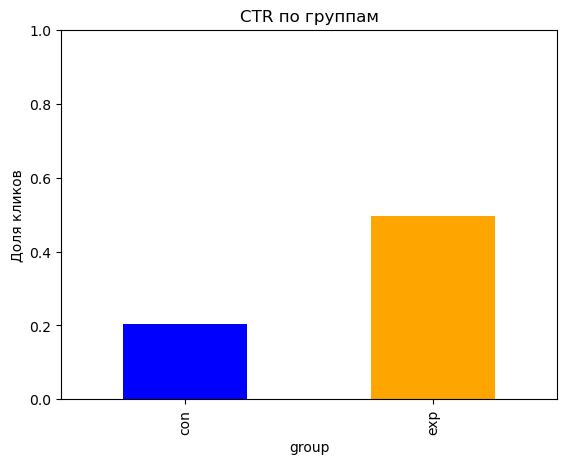

In [16]:
# Визуализация
ctr.plot(kind='bar', color=['blue', 'orange'])
plt.title('CTR по группам')
plt.ylabel('Доля кликов')
plt.ylim(0, 1)
plt.show()

**Наблюдение:** CTR в экспериментальной группе выше, чем в контрольной. Проверим, является ли разница статистически значимой.

### 4.3. Выбор метода

Так как метрика бинарная (`click`), для сравнения двух групп используем **Z-тест для пропорций**.  
Этот тест позволяет проверить, значимо ли различаются доли кликов в группах.

**Проверка предположений:**
- Независимость наблюдений — выполнена (пользователи не пересекаются, учавствуют только в одной группе).
- Достаточный размер выборки — проверяем ниже.

In [17]:
# Размеры групп
n_con = df[df['group'] == 'con'].shape[0]
n_exp = df[df['group'] == 'exp'].shape[0]

print(f"Размер контрольной группы: {n_con}")
print(f"Размер экспериментальной группы: {n_exp}")

Размер контрольной группы: 99972
Размер экспериментальной группы: 98047


Размер выборки достаточен для Z-теста (n > 30 в каждой группе).

### 4.4. Проверка валидности: A/A-тест

Чтобы убедиться, что инструмент не даёт ложных срабатываний, проведём A/A-тест:
- Разделим **контрольную группу** на две случайные подгруппы.
- Проверим, есть ли между ними значимая разница.

In [18]:
# Случайное разделение контрольной группы на две части
import numpy as np
np.random.seed(17)

control_df = df[df['group'] == 'con'].copy()
control_df['aa_group'] = np.random.choice(['aa_con', 'aa_exp'], size=len(control_df), replace=True)

# Расчёт CTR для A/A групп
ctr_aa = control_df.groupby('aa_group')['click'].mean()
print("CTR для A/A групп:")
print(ctr_aa)

CTR для A/A групп:
aa_group
aa_con    0.204398
aa_exp    0.204057
Name: click, dtype: float64


In [19]:
# Проверка различий A/A групп
from statsmodels.stats.proportion import proportions_ztest

counts_aa = control_df.groupby('aa_group')['click'].sum()
nobs_aa = control_df.groupby('aa_group')['click'].count()

stat, p = proportions_ztest(
    count=[counts_aa.iloc[0], counts_aa.iloc[1]],
    nobs=[nobs_aa.iloc[0], nobs_aa.iloc[1]]
)
print(f"p-value для A/A-теста: {p:.4f}")

p-value для A/A-теста: 0.8937


**Результат:** p-value = 0.8937 ≥ 0.05 → разница между A/A группами статистически незначима. Это подтверждает корректность инструмента.

### 4.5. Проведение A/B-теста (Z-тест для пропорций)

In [20]:
from statsmodels.stats.proportion import proportions_ztest

# Подсчёт кликов и общего числа пользователей в каждой группе
counts = df.groupby('group')['click'].sum()
nobs = df.groupby('group')['click'].count()

# Z-тест (двусторонний)
stat, p_value = proportions_ztest(
    count=[counts['con'], counts['exp']],
    nobs=[nobs['con'], nobs['exp']]
)

print(f"Z-статистика: {stat:.4f}")
print(f"p-value: {p_value:.6f}")

Z-статистика: -136.3193
p-value: 0.000000


**Интерпретация:** p-value = 0.000000 < 0.05 → нулевая гипотеза отвергается. Разница между группами статистически значима.

## Финальные выводы

- **A/B-тест:** p-value ≈ 0 < 0.05 → нулевая гипотеза отвергается.  
  CTR вырос с 20.4% (контроль) до 49.6% (эксперимент) — **+29.2 %**  

- **Эффект:** сильный, статистически и практически значимый.  

- **Валидность:** A/A-тест (p-value = 0.8937) подтверждает корректность инструмента.  

- **Рекомендация:** внедрять изменение, возмможны дополнительные проверки по сегментам.